In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.jpg to images (1).jpg


(np.float64(-0.5), np.float64(299.5), np.float64(167.5), np.float64(-0.5))

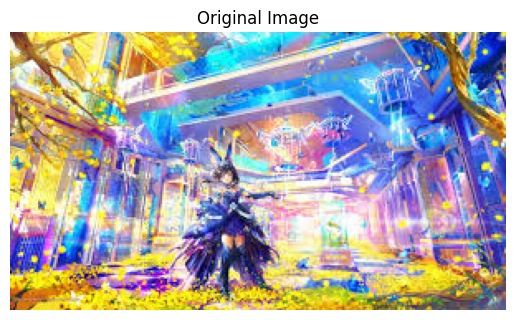

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('images.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')


In [ ]:
import numpy as np

pixels = img.reshape((-1, 3))
pixels = np.float32(pixels)

#Each pixel → [R, G, B]

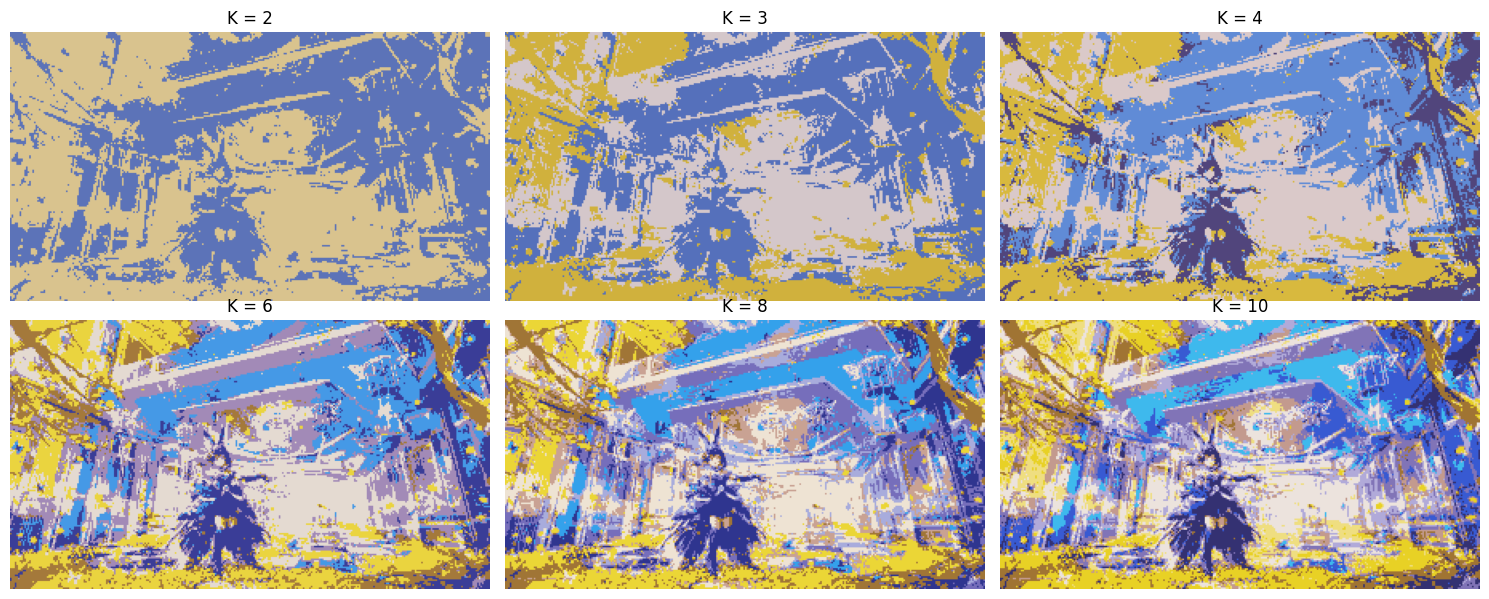

In [ ]:
from sklearn.cluster import KMeans

k_values = [2, 3, 4, 6, 8, 10]

plt.figure(figsize=(15, 6))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)

    centers = np.uint8(kmeans.cluster_centers_)
    segmented_pixels = centers[labels]
    segmented_image = segmented_pixels.reshape(img.shape)

    plt.subplot(2, 3, i+1)
    plt.imshow(segmented_image)
    plt.title(f"K = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()


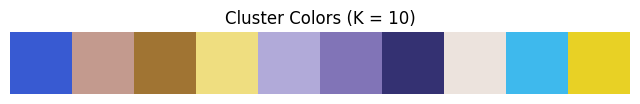

In [ ]:
k = 10
# create palette
palette = centers.reshape(1, k, 3)

plt.figure(figsize=(8, 2))
plt.imshow(palette)
plt.title("Cluster Colors (K = 10)")
plt.axis("off")
plt.show()

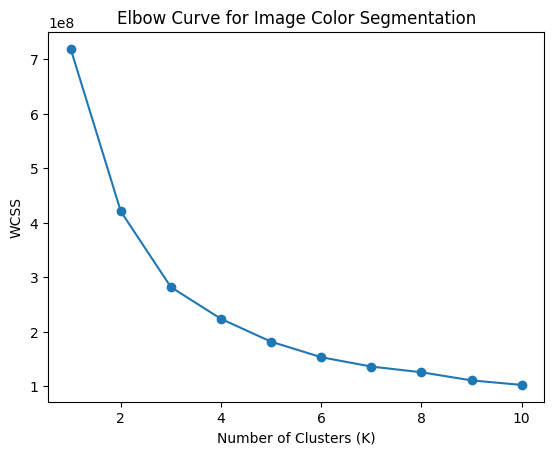

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] #Within-Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Curve for Image Color Segmentation")
plt.show()
